# Exploratory Data Analysis

## CRISP-DM Phase 4: Exploratory Data Analysis

### Project: Customer Churn Analysis

Exploratory Data Analysis (EDA) is the process of examining, summarizing, and visualizing the cleaned dataset to understand customer behavior, identify patterns, detect relationships between variables, and discover factors that may influence customer churn.

The objectives of this notebook are to:

- Load the cleaned customer churn dataset
- Inspect the structure and summary statistics of the dataset
- Analyze the distribution of numerical variables
- Analyze categorical variables and their frequencies
- Examine the distribution of the target variable (Churn)
- Identify patterns and trends in customer behavior
- Analyze relationships between customer characteristics and churn
- Compare churn rates across different categorical segments
- Investigate correlations among numerical variables
- Identify important features associated with customer churn
- Use appropriate visualizations to communicate key findings
- Summarize the major insights obtained from the analysis

### Input
Cleaned customer churn dataset

### Output
Exploratory analysis containing statistical summaries, visualizations, relationships, patterns, and key business insights related to customer churn.

### Key Areas of Analysis

- **Univariate Analysis:** Understanding individual numerical and categorical variables
- **Bivariate Analysis:** Examining relationships between individual features and churn
- **Multivariate Analysis:** Exploring interactions and relationships among multiple variables
- **Churn Analysis:** Identifying customer characteristics and behaviors associated with higher churn rates
- **Correlation Analysis:** Understanding relationships between numerical features
- **Visualization:** Using charts and plots to identify meaningful patterns and trends
- **Business Insights:** Translating analytical findings into actionable insights for reducing customer churn


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="dark")
print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
engine = create_engine(
    f"postgresql://{DB_CONFIG["user"]}:{DB_CONFIG["password"]}@{DB_CONFIG["host"]}:{DB_CONFIG["port"]}/{DB_CONFIG["database"]}"
)

query = "SELECT * FROM customer_churn;"
customer_churn = pd.read_sql(query, engine)

customer_churn.head()

,customerid,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,...,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


## 1. What is the percentage of churn rate?

In [4]:
churn_counts = customer_churn['churn_label'].value_counts()
churn_percentage = (churn_counts['Yes'] / churn_counts.sum()) * 100
print(f"The percentage of customers that have churned is: {churn_percentage:.2f}%")

The percentage of customers that have churned is: 26.54%


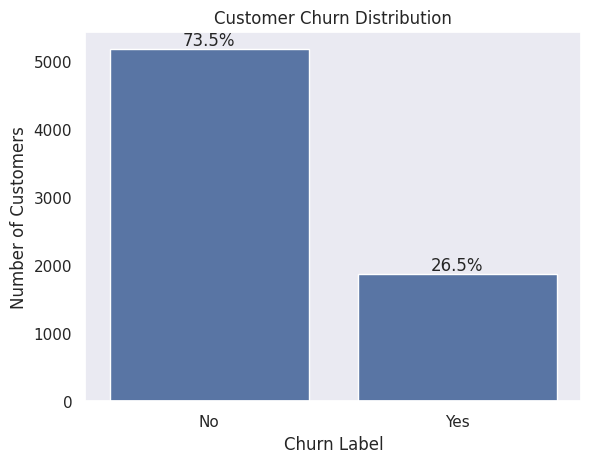

In [5]:
sns.barplot(
    x = churn_counts.index,
    y = churn_counts.values
)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Number of Customers")

for i, value in enumerate(churn_counts.values):
    percentage = (value / churn_counts.sum()) * 100
    plt.text(i, value, f"{percentage:.1f}%", ha="center", va="bottom")
plt.show()

### Initial Observations
- The overall churn percentage is approximately 26.5%.

## 2. What is the average total_charges?

In [6]:
print(f"The average total_charges is: ${customer_churn['total_charges'].mean():.2f}")

The average total_charges is: $2279.73


### Initial Observations
- The average `total_charges` are $2279.73

## 3. Which type of contract is most widely preferred?

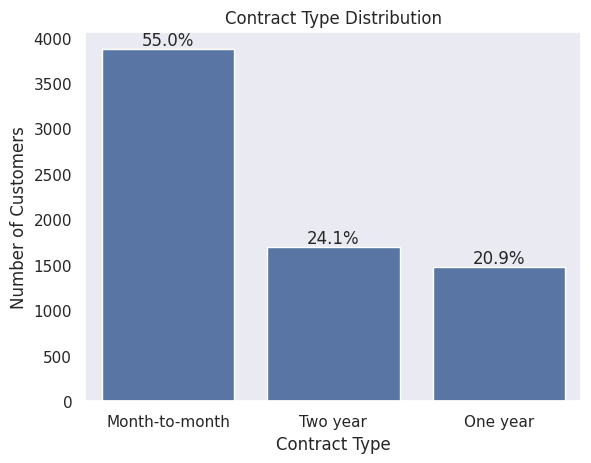

In [7]:
contract_counts = customer_churn['contract'].value_counts()
sns.barplot(
    x = contract_counts.index,
    y = contract_counts.values
)
plt.title("Contract Type Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

for i, value in enumerate(contract_counts.values):
    percentage = (value / contract_counts.sum()) * 100
    plt.text(i, value, f"{percentage:.1f}%", ha="center", va="bottom")
plt.show()

#### Initial Observations
- Based on the observations above, the **Month-to-month** `contract type` is the most preferred option, with approximately 5**5% of customers opting for it**.

## 4. What is the distribution of reason of churn?

In [8]:
reason_of_churn_top_5 = (
    customer_churn[customer_churn['churn_reason'] != 'Not Applicable']
    ['churn_reason']
    .value_counts()
    .head(5)
)

reason_of_churn_top_5

churn_reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Name: count, dtype: int64

#### Initial Observations
Based on the observations following are the top 5 reasons for customer churn:
- Attitude of support person
- Competitor offered higher download speeds
- Competitor offered more data
- Don't know
- Competitor made better offer 

## 5. What is the relationship between senior citizen status and customer churn?

In [9]:
senior_citizen_percentage = (
    customer_churn.groupby('senior_citizen')['churn_label']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

for group, percentage in senior_citizen_percentage.items():
    status = "Senior citizens" if group == 1 else "Non-senior citizens"
    print(f"The churn rate for {status} is: {percentage:.2f}%")

The churn rate for Non-senior citizens is: 23.61%
The churn rate for Non-senior citizens is: 41.68%


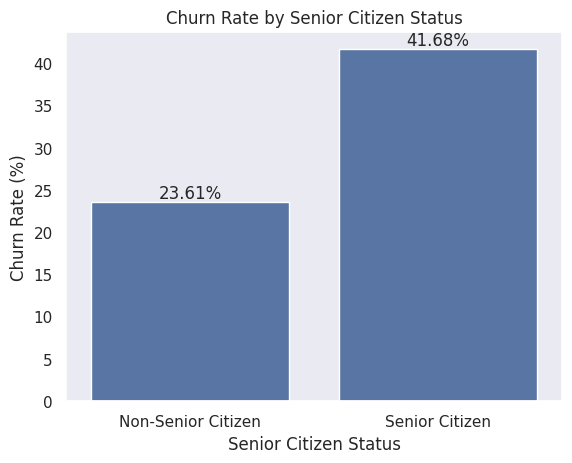

In [10]:
sns.barplot(
    x=senior_citizen_percentage.index,
    y=senior_citizen_percentage.values
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen Status")
plt.ylabel("Churn Rate (%)")

plt.xticks([0, 1], ["Non-Senior Citizen", "Senior Citizen"])

for i, value in enumerate(senior_citizen_percentage.values):
    plt.text(i, value, f"{value:.2f}%", ha="center", va="bottom")

plt.show()

#### Initial Observations
- The percentage who have senior citizen that have churned is: 41.68%.
- The percentage who have non-senior citizen that have churned is: 23.61%

## 6. What is the average tenure_months?

In [11]:
print(f"The average tenure months is: {customer_churn['tenure_months'].mean():.2f} months")

The average tenure months is: 32.37 months


#### Initial Observations
- The average tenure months is: 32.37 months

## 7. What is the churn rate among established and non-established customers?

##### For the purpose of this analysis, customers with a tenure of more than 13 months will be classified as **established customers**.

In [12]:
customer_churn['is_established'] = customer_churn['tenure_months'].apply(
    lambda x: 'Yes' if x > 13 else 'No'
)
customer_churn.head()

,customerid,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,...,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason,is_established
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,No
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,No
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,No
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,Yes
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,Yes


In [13]:
established_customer_churned_percentage = customer_churn.groupby('is_established')['churn_label'].apply(lambda x: (x == 'Yes').mean() * 100)

In [14]:
established_customer_churned_percentage
for group, percentage in established_customer_churned_percentage.items():
    status = "Not Established" if group == 'No' else "Established"
    print(f"The churn rate for {status} is: {percentage:.2f}%")

The churn rate for Not Established is: 46.84%
The churn rate for Established is: 16.72%


#### Initial Observations
- The churn rate among established customers is 16.72%, compared with 46.84% among non-established customers. This indicates that non-established customers have a substantially higher churn rate.

In [ ]:
# Saving the cleaned dataset to Postgresql database
customer_churn.to_sql(
    "customer_churn_clean_eda",
    engine,
    if_exists="replace",
    index=False
)

In [ ]:
# Processed Data Path
PROCESSED_DATA_PATH = Path("data/processed/customer_churn_clean_EDA.csv")

In [ ]:
customer_churn.to_csv('PROCESSED_DATA_PATH')

# Final Summary — Basic EDA

The basic exploratory data analysis provided an overall understanding of the customer base and established several important characteristics of the dataset.

### Key Observations

- The dataset contains a meaningful proportion of **churned customers**, providing a baseline for the customer churn problem.
- The average `total_charges` is **$2,279.73**, representing the typical total amount charged to a customer.
- The **Month-to-month contract** is the most common contract type, accounting for approximately **55% of customers**.
- Among churned customers, the most frequently reported churn reasons include **attitude of the support person, competitive offers, higher competitor download speeds, and competitors offering more data**.
- **Senior citizens have a higher churn rate (41.68%)** compared with non-senior citizens (23.61%).
- The average customer tenure is **32.37 months**.
- Based on the analytical definition used in this analysis, customers with **more than 13 months of tenure** are classified as established customers.
- **Established customers have a churn rate of 16.72%**, while **non-established customers have a churn rate of 46.84%**.
- The distribution of additional services provides an overview of how customers utilize the available services and will be useful for further churn analysis.

### Overall Conclusion

The Basic EDA provides a clear overview of the customer base and highlights several variables that may be relevant to customer churn, particularly **contract type, tenure, senior citizen status, and additional services**.

The observations made at this stage are primarily **descriptive** and should not be interpreted as causal relationships. The purpose of this analysis is to understand the dataset and identify areas that require further investigation.

The next stage will therefore focus on **Deep-Dive EDA**, where relationships between customer characteristics and churn will be analyzed in greater detail.